In [8]:
!pip install numpy matplotlib scikit-learn opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
    --------------------------------------- 0.5/40.2 MB 5.6 MB/s eta 0:00:08
   -- ------------------------------------- 2.4/40.2 MB 7.5 MB/s eta 0:00:06
   --- ------------------------------------ 3.4/40.2 MB 6.5 MB/s eta 0:00:06
   ---- ----------------------------------- 4.7/40.2 MB 6.5 MB/s eta 0:00:06
   ----- ---------------------------------- 5.8/40.2 MB 6.1 MB/s eta 0:00:06
   ------ --------------------------------- 6.8/40.2 MB 5.8 MB/s eta 0:00:06
   -------- ------------------------------- 8.1/40.2 MB 5.4 MB/s eta 0:00:06
   --------- ------------------------------ 9.2/40.2 MB 5.4 MB/s eta 0:00:06
   ---------- ----------------------------- 10.5/40.2 MB 5.4 MB/s eta 0:00:06
   ----------- ---------------------------- 11.5/40.2 MB 5.3 MB/s eta 0:00:06
   ------------ --------------------------- 12.3/40.2 MB 5.2 MB/s eta 0:00:06
   ------------- -------------------------- 13.1/40.2 MB 5.2 MB/s eta 0:00:06
  

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2

from PIL import Image
# model Support Vector Machine
from sklearn.svm import SVC, LinearSVC
# funkcje do generowania przykładowych zbiorów danych
from sklearn.datasets import make_blobs, make_moons, make_circles
# algorytm PCA (do redukcji wymiarów danych)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# pozwala łączyć kilka kroków przetwarzania danych w jeden pipelin
from sklearn.pipeline import make_pipeline
# funkcja do mierzenia dokładności modelu
from sklearn.metrics import accuracy_score

In [10]:
def load_images(folder, size=(96, 96), grayscale=True):
    X = []
    y = []
    
    #tworzymy liste klas
    class_names = sorted(os.listdir(folder))

    #kazdemu gatunkowi przypisujemy numer
    for label, class_name in enumerate(class_names):
        class_path = os.path.join(folder, class_name)
        

        for filename in os.listdir(class_path):
            file_path = os.path.join(class_path, filename)
            
            #obrazy na czarno-biale i skalowanie
            img = Image.open(file_path).convert("L")
            img = img.resize((96, 96))

            #obraz->macierz->wektor
            X.append(np.array(img).flatten())
            y.append(label)
            
    return np.array(X), np.array(y), class_names

In [21]:
X_train, y_train, class_names = load_images("data/Train_Test_Valid/Train")
X_test, y_test, class_names = load_images("data/Train_Test_Valid/test")

Klasy: ['Moon_jellyfish', 'barrel_jellyfish', 'blue_jellyfish', 'compass_jellyfish', 'lions_mane_jellyfish', 'mauve_stinger_jellyfish']
X_train shape: (900, 9216)
y_train shape: (900,)


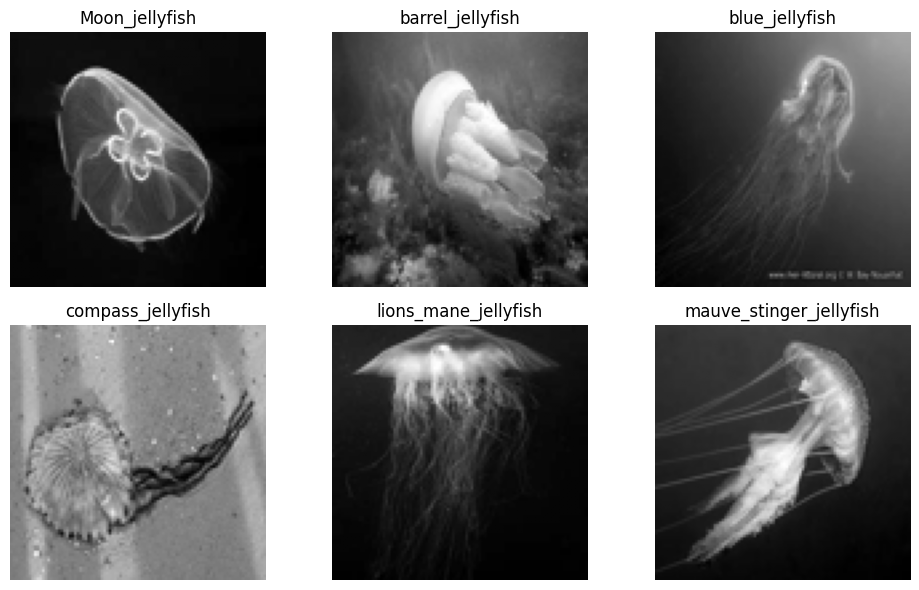

In [22]:
print("Klasy:", class_names)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
#900 obrazow, 9216cech

fig, ax = plt.subplots(2, 3, figsize=(10, 6))
for label, axi in enumerate(ax.flat):
    idx = np.where(y_train == label)[0][0]   # pierwszy obraz z danej klasy
    axi.imshow(X_train[idx].reshape(96, 96), cmap="gray")
    axi.set_title(class_names[label])
    axi.axis("off")

plt.tight_layout()
plt.show()

In [31]:
#spr

from collections import Counter

counts = Counter(y_train)

for label, count in counts.items():
    print(label, ":", count)

0 : 150
1 : 150
2 : 150
3 : 150
4 : 150
5 : 150


In [23]:
pca = PCA(n_components=200, whiten=True, svd_solver='randomized', random_state=42)
svc = SVC(kernel='rbf', class_weight='balanced')
model = make_pipeline(pca, svc)

In [24]:
from sklearn.model_selection import GridSearchCV

#szukamy najlepszych parametrów do modelu
param_grid = {
    'svc__C': [1, 5, 10, 50],
    'svc__gamma': [0.0001, 0.0005, 0.001, 0.005]
}

grid = GridSearchCV(model, param_grid)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'svc__C': 5, 'svc__gamma': 0.005}


In [28]:
model = grid.best_estimator_
y_pred = model.predict(X_test)

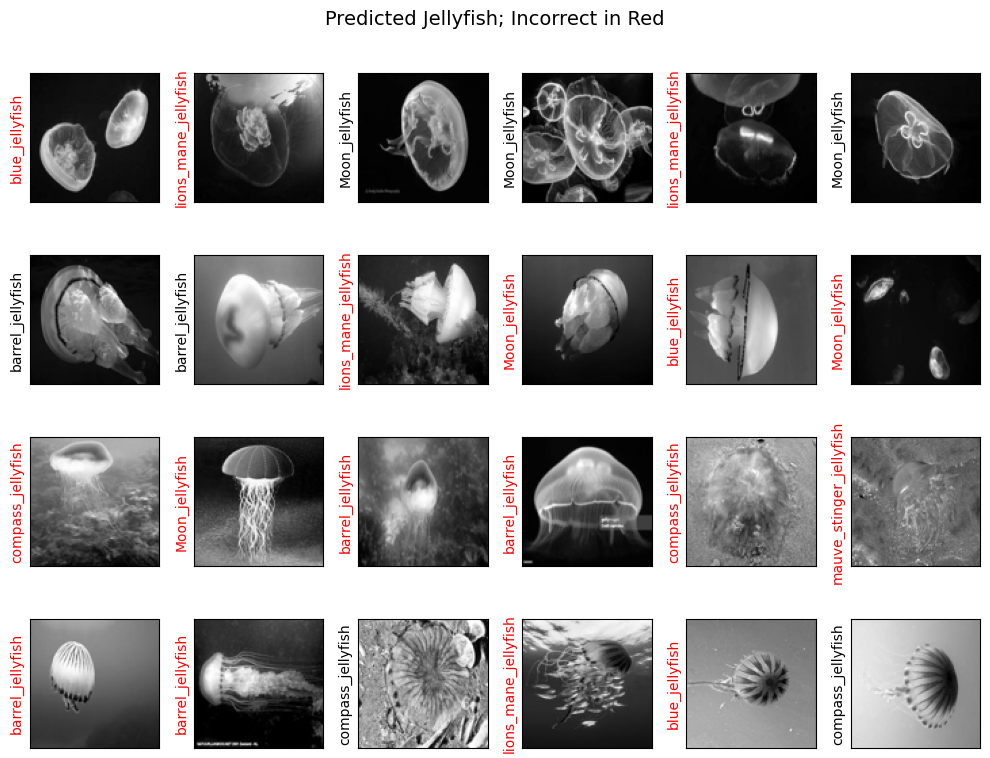

In [29]:
fig, ax = plt.subplots(4, 6, figsize=(10, 8))
for i, axi in enumerate(ax.flat):
    axi.imshow(X_test[i].reshape(96, 96), cmap='gray')
    axi.set(xticks=[], yticks=[])

    axi.set_ylabel(
        class_names[y_pred[i]],
        color='black' if y_pred[i] == y_test[i] else 'red'
    )

fig.suptitle('Predicted Jellyfish; Incorrect in Red', size=14)
plt.tight_layout()
plt.show()

In [31]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred,
                            target_names=class_names))

                         precision    recall  f1-score   support

         Moon_jellyfish       0.30      0.50      0.38         6
       barrel_jellyfish       0.29      0.40      0.33         5
         blue_jellyfish       0.00      0.00      0.00         7
      compass_jellyfish       0.50      0.43      0.46         7
   lions_mane_jellyfish       0.20      0.25      0.22         8
mauve_stinger_jellyfish       0.50      0.29      0.36         7

               accuracy                           0.30        40
              macro avg       0.30      0.31      0.29        40
           weighted avg       0.30      0.30      0.29        40

